In [36]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

In [37]:
torch.manual_seed(42) 

In [38]:
df = pd.read_csv('./fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


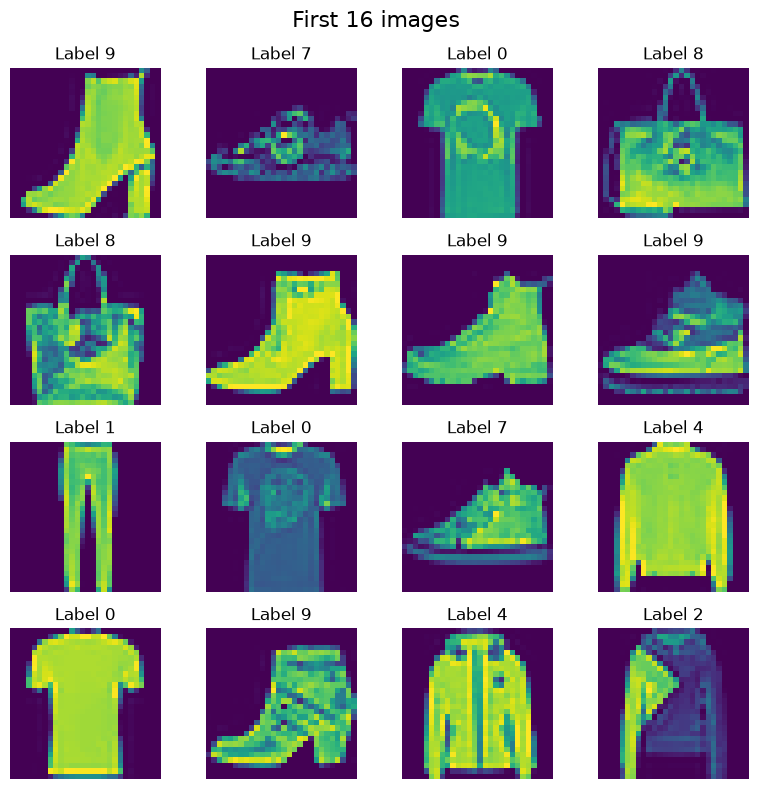

In [39]:
fig,axes = plt.subplots(4,4,figsize=(8,8))

fig.suptitle("First 16 images ", fontsize=16)

for index,ax in enumerate(axes.flat):
    image = df.iloc[index,1:].values.reshape(28,28)
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(f"Label {df.iloc[index,0]}")
plt.tight_layout()
plt.show()


In [40]:
X = df.iloc[:,1:]
y = df.iloc[:,0]
X_train, X_test,y_train,y_test = train_test_split(
    X,
    y,
    random_state = 42,
    test_size = 0.2
)
# scaling the feautures
X_train = X_train/255.0
y_train = y_train/255.0

In [ ]:
class CustomDataset(Dataset):
    def __init__(self,features,labels):
        self.features = features
        self.labels = labels
    def __len__(self):
        return len(self.features)
    def __getitem__(self,index):
        return self.features[index],self.labels[index]

In [42]:
train_dataset = CustomDataset(X_train,X_test)
test_dataset = CustomDataset(y_train,y_test)

In [43]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [44]:
class MyNN (nn.Module):
    def __init__(self,num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10),
    )
def forward (self,X):
    return self.model(X)

In [46]:
epochs = 10
learning_rate = 0.1

model = MyNN(X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),lr=learning_rate)

for epoch in range(epochs):
  total_epoch_loss = 0
  
  for batch_features,batch_labels in train_loader:
    #forward pass
    output = model(batch_features)

    #calculate loss
    loss = criterion(output,batch_labels)

    #back pass
    optimizer.zero_grad()
    loss.backward()

    #update
    optimizer.step()

    # print(loss.item())
    total_epoch_loss = total_epoch_loss + loss.item()


avg_loss = total_epoch_loss / len(train_loader)

print(avg_loss)







IndexError: single positional indexer is out-of-bounds